# Regresión Geoespacial

Daniel Núñez Vargas

In [1]:
# Librerias base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Librerias que permiten trabajar con datos geoespaciales
import geopandas as gpd
from libpysal import weights
import esda
import spreg
from splot import esda as esdaplot
from splot.esda import plot_moran

# Para el análisis descriptivo inicial de contraste de asociación  
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.metrics import mean_squared_error, r2_score

# Librería para hacer la tramificación, agrupación y transformación WOE
from optbinning import Scorecard, BinningProcess, OptimalBinning
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks, ScorecardMonitoring

from Funciones import * # Script donde se han incluido variedad de funciones personalizadas

## Carga de información

In [2]:
# Carga de los datos 
df_train_raw = gpd.read_file('../Input/ModelingDatasets/Train/df_train_with_score_ZCTACoordinates.shp')
# Se cambian los nombres que se perdieron al guardar el archivo en formato .shp
df_train = cleanDataframe2(df_train_raw)
df_train.head(3)

,dc_dist,psa,date,hour,crime_description,id,time_of_day,day_of_week,week_of_year,month,...,mean_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry
0,16,1,2023-12-31,19,Thefts,6236,Afternoon,Sunday,52,December,...,59711.0,19948,35.8,22.5,32.9,8.7,0.5465,0.385733,Low,"POLYGON ((-75.21367 39.96003, -75.21204 39.959..."
1,14,1,2023-12-31,19,Theft from Vehicle,9278,Afternoon,Sunday,52,December,...,65880.0,12823,28.3,20.5,45.4,5.6,0.4680,0.403961,Low,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518..."
2,25,1,2023-12-31,19,Other Assaults,9381,Afternoon,Sunday,52,December,...,51112.0,20557,39.7,26.8,29.9,3.6,0.5170,0.528764,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008..."


In [3]:
# Informacion general de los datos de entrenamiento
df_train.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 159762 entries, 0 to 159761
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   dc_dist                 159762 non-null  int64         
 1   psa                     159711 non-null  object        
 2   date                    159762 non-null  datetime64[ms]
 3   hour                    159762 non-null  int32         
 4   crime_description       159762 non-null  object        
 5   id                      159762 non-null  int64         
 6   time_of_day             159762 non-null  object        
 7   day_of_week             159762 non-null  object        
 8   week_of_year            159762 non-null  int64         
 9   month                   159762 non-null  object        
 10  season                  159762 non-null  object        
 11  is_holiday              159762 non-null  bool          
 12  crimeType             

# Análisis 

In [ ]:
# Se hace agrupamiento
aggregate_df_train_raw = df_train.groupby(['ZCTA', 'time_of_day']).agg({
    'geometry': 'first',
    'population' : 'first', 
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# Se remueven NAs
aggregate_df_train = aggregate_df_train_raw.dropna().reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_train = gpd.GeoDataFrame(aggregate_df_train, geometry='geometry')
# Resumen 
aggregate_df_train.head(3)

# aggregate_df_train.to_csv("RiskScore_MediaZCTA_Train.csv")

,index,ZCTA,time_of_day,geometry,population,white_race,black_race,latino_race,asian_race,mean_income,median_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score
0,0,19004,Night,"POLYGON ((-75.24583 40.02155, -75.24562 40.023...",10668,8284,529,448,998,217722.0,143781.0,4216,11.3,5.4,37.4,45.8,0.5115,0.056829
1,1,19012,Night,"POLYGON ((-75.12187 40.05327, -75.12144 40.053...",6699,2792,2413,602,738,144838.0,117614.0,2237,5.4,10.6,46.1,37.8,0.4036,0.163235
2,2,19027,Afternoon,"POLYGON ((-75.15366 40.07214, -75.15332 40.072...",19170,8927,7207,1092,1231,136486.0,105190.0,8417,13.0,11.9,42.2,32.8,0.4608,0.036326


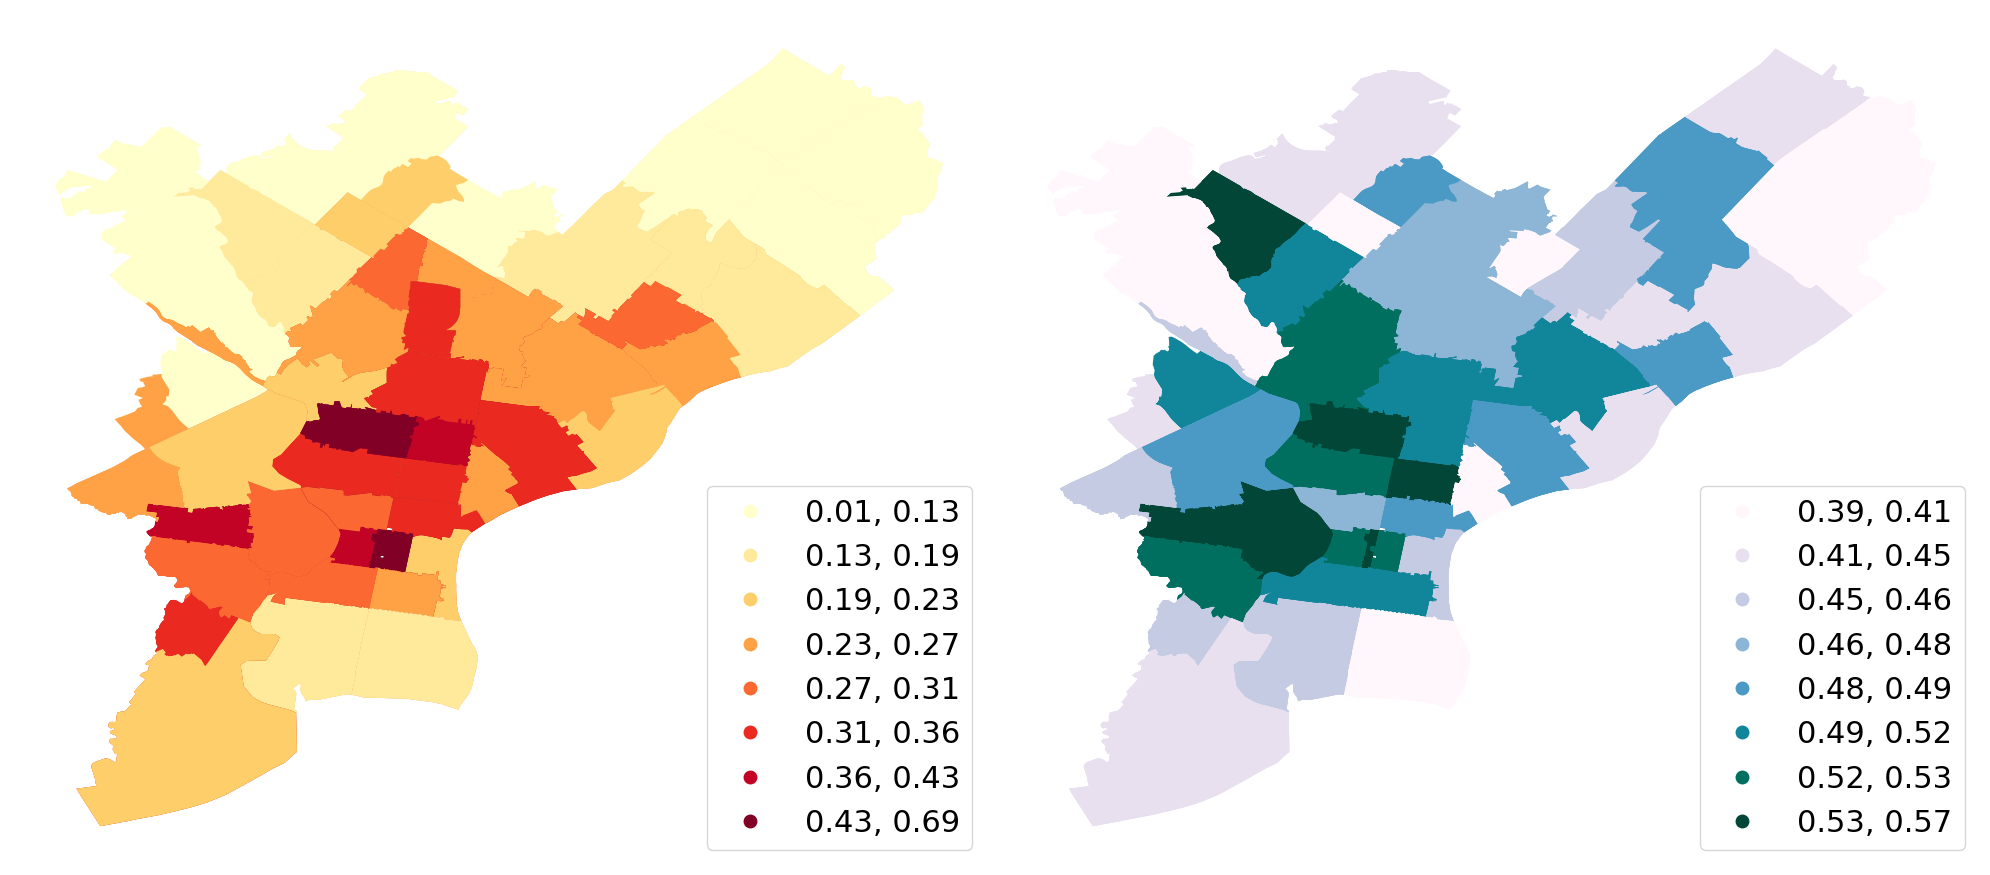

In [58]:
# Crear una figura con subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: Risk Score
map1 = aggregate_df_train.plot(column='risk_score', 
                              scheme='quantiles',
                              k=8, 
                              cmap='YlOrRd',
                              legend=True,
                              ax=axes[0],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[0].set_axis_off()
# axes[0].set_title('Distribución del Score de Riesgo', fontsize=14, pad=20)

# Mapa 2: Gini Index
map2 = aggregate_df_train.plot(column='GiniIndex', 
                              scheme='quantiles',
                              k=8, 
                              cmap='PuBuGn',
                              legend=True,
                              ax=axes[1],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[1].set_axis_off()
# axes[1].set_title('Distribución del Índice de Gini', fontsize=14, pad=20)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

# Matriz de pesos Espaciales

In [59]:
wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_2508\1756804908.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)


In [60]:
print(wq.n)

150


In [61]:
# No hay islas
wq.islands

[]

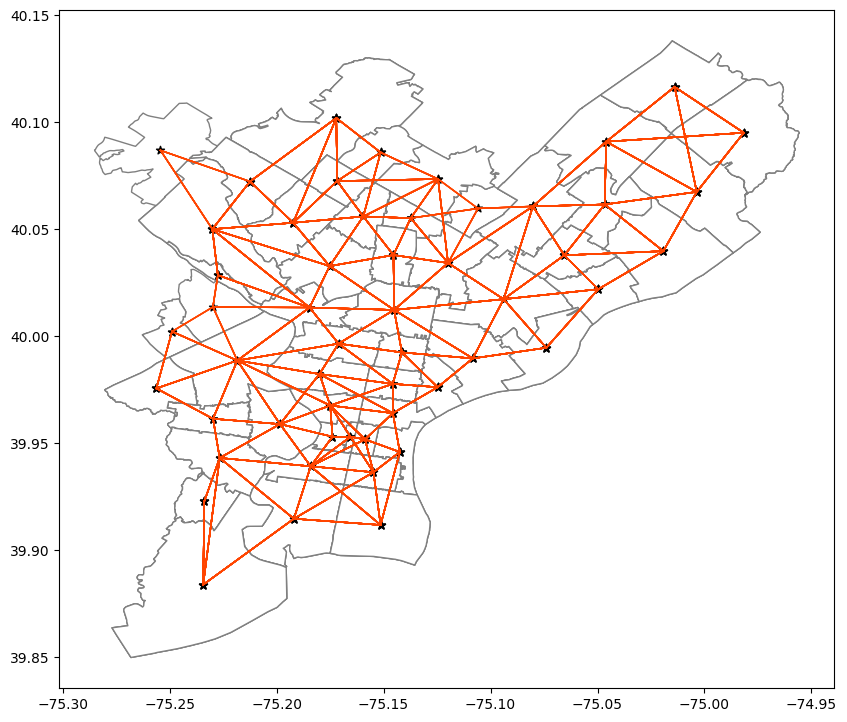

In [62]:
# Plot graph connections
ax = aggregate_df_train.plot(
        edgecolor="grey", facecolor="w",
        figsize=(10,10)
    )

wq.plot(
    aggregate_df_train,
    edge_kws=dict(linewidth=1, color="orangered"),
    node_kws=dict(marker="*"),
    ax=ax
)

plt.show()

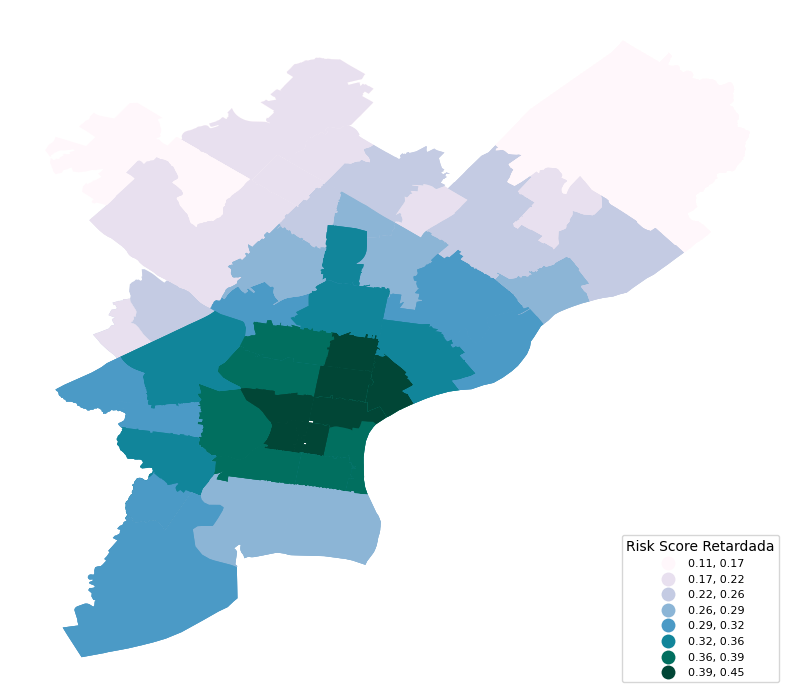

In [63]:
# Transformar pesos por filas
wq.transform = "R"

# Creación de variables con retardo espacial
aggregate_df_train["risk_score_lag"] = weights.spatial_lag.lag_spatial(
    wq, aggregate_df_train["risk_score"]
)

# representación de la tasa de paro retardada
map=aggregate_df_train.plot(column='risk_score_lag', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Risk Score Retardada'} 
)
map.set_axis_off() 

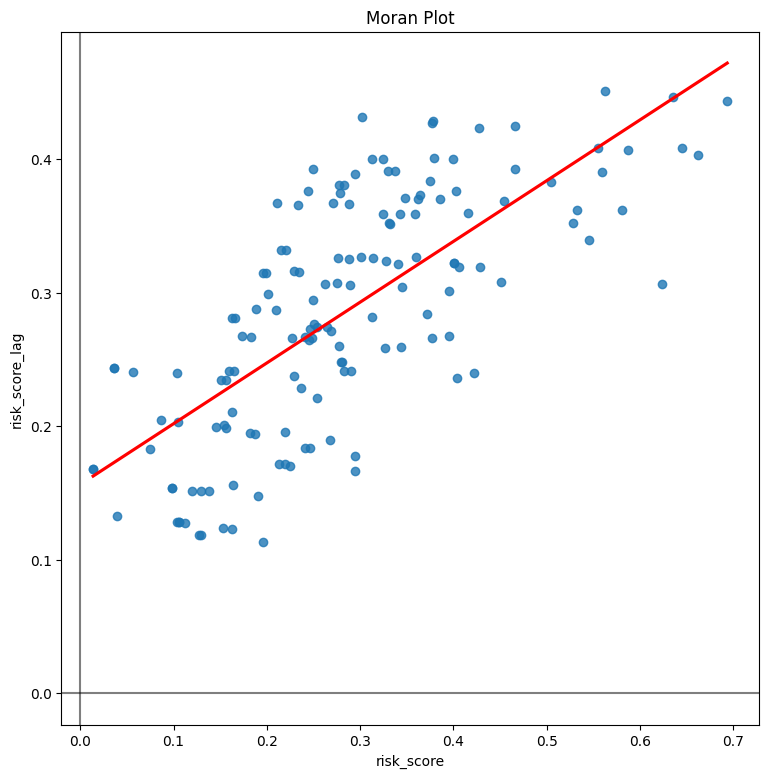

In [ ]:
# AutoCorrelación Espacial
f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="risk_score",
    y="risk_score_lag",
    ci=None,
    data=aggregate_df_train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot")
plt.show()

# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(aggregate_df_train["risk_score"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

In [14]:
# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(aggregate_df_train["risk_score"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

I de moran: 0.455
p-valor: 0.001


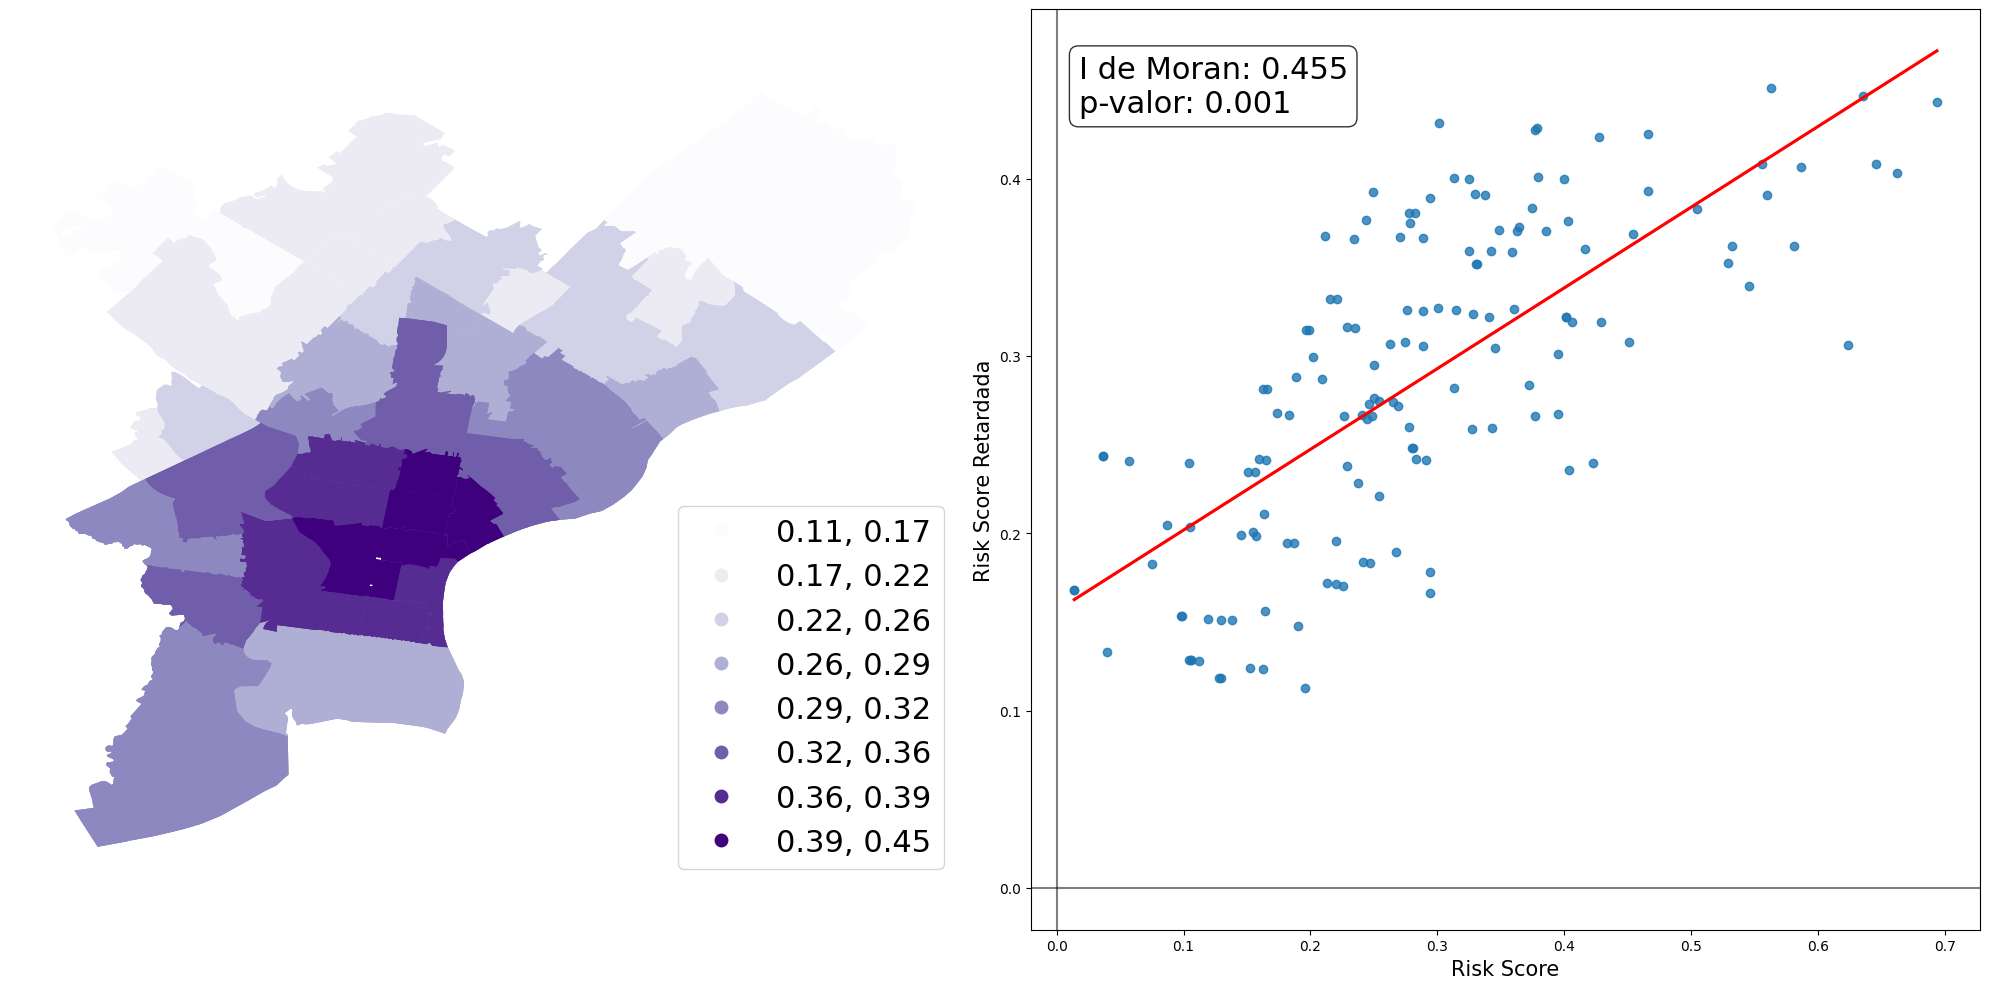

In [79]:
# Creación de variables con retardo espacial
aggregate_df_train["risk_score_lag"] = weights.spatial_lag.lag_spatial(
    wq, aggregate_df_train["risk_score"]
)

# Crear una figura con subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa: Risk Score Retardada
map1 = aggregate_df_train.plot(column='risk_score_lag', 
                              scheme='quantiles',
                              k=8, 
                              cmap='Purples',
                              legend=True,
                              ax=axes[0],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[0].set_axis_off()
# axes[0].set_title('Risk Score con Retardo Espacial', fontsize=14, pad=20)

# Diagrama de Moran con estadísticas
sns.regplot(
    x="risk_score",
    y="risk_score_lag",
    ci=None,
    data=aggregate_df_train,
    line_kws={"color": "r"},
    ax=axes[1]
)
axes[1].axvline(0, c="k", alpha=0.5)
axes[1].axhline(0, c="k", alpha=0.5)

# Calcular la I de Moran
moran = esda.moran.Moran(aggregate_df_train["risk_score"], wq)

# Añadir las estadísticas al gráfico
# Añadir las estadísticas dentro del gráfico
axes[1].text(0.05, 0.95, f"I de Moran: {moran.I:.3f}\np-valor: {moran.p_sim:.3f}", 
            transform=axes[1].transAxes, fontsize=22, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
axes[1].set_xlabel('Risk Score', fontsize=15)
axes[1].set_ylabel('Risk Score Retardada', fontsize=15)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

In [15]:
#Correlación Espacial Local
lisa = esda.moran.Moran_Local(aggregate_df_train["risk_score"], wq, seed=42)

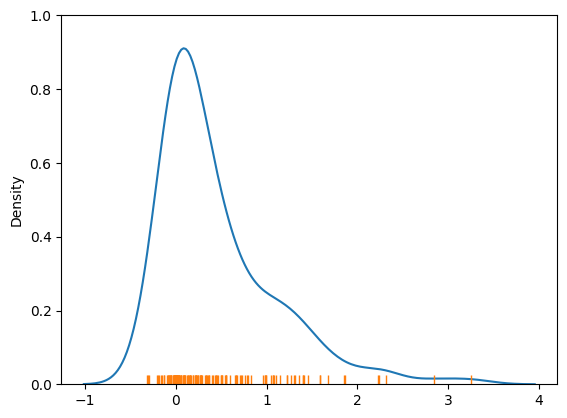

In [16]:
#Correlación Espacial Local
#Representación del Indice de Moran Local (Is)
# Draw KDE line
ax = sns.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
sns.rugplot(lisa.Is, ax=ax);

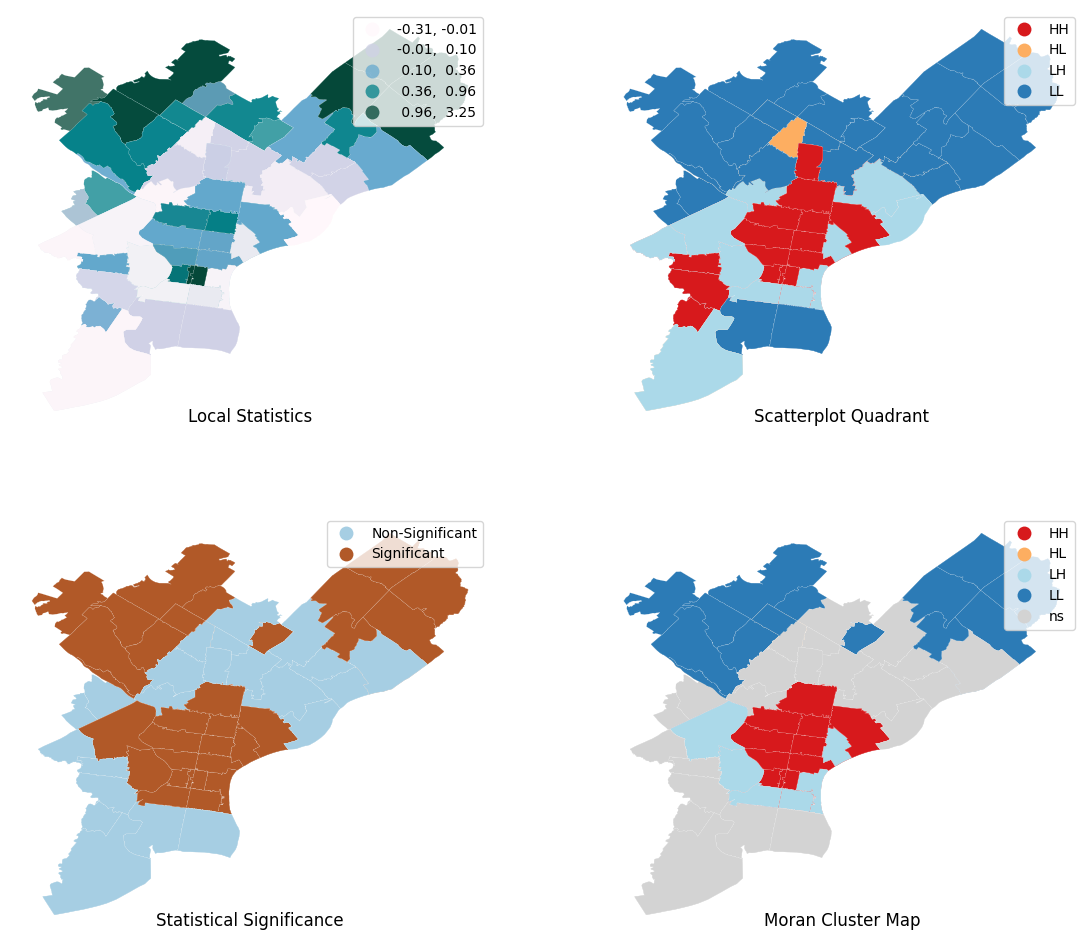

In [17]:
# Set up figure and axes
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
# Make the axes accessible with single indexing
axs = axs.flatten()

# Subplot 1 #
# Choropleth of local statistics
# Grab first axis in the figure
ax = axs[0]
# Assign new column with local statistics on-the-fly
aggregate_df_train.assign(
    Is=lisa.Is
    # Plot choropleth of local statistics
).plot(
    column="Is",
    cmap="PuBuGn",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    alpha=0.75,
    legend=True,
    ax=ax,
)

# Subplot 2 #
# Quadrant categories
# Grab second axis of local statistics
ax = axs[1]
# Plot Quandrant colors (note to ensure all polygons are assigned a
# quadrant, we "trick" the function by setting significance level to
# 1 so all observations are treated as "significant" and thus assigned
# a quadrant color
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=1, ax=ax)

# Subplot 3 #
# Significance map
# Grab third axis of local statistics
ax = axs[2]
#
# Find out significant observations
labels = pd.Series(
    1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
    index=aggregate_df_train.index  # Use the index in the original data
    # Recode 1 to "Significant and 0 to "Non-significant"
).map({1: "Significant", 0: "Non-Significant"})
# Assign labels to `db` on the fly
aggregate_df_train.assign(
    cl=labels
    # Plot choropleth of (non-)significant areas
).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
)


# Subplot 4 #
# Cluster map
# Grab second axis of local statistics
ax = axs[3]
# Plot Quandrant colors In this case, we use a 5% significance
# level to select polygons as part of statistically significant
# clusters
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=0.05, ax=ax)

# Figure styling #
# Set title to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    ax.set_title(
        [
            "Local Statistics",
            "Scatterplot Quadrant",
            "Statistical Significance",
            "Moran Cluster Map",
        ][i],
        y=0,
    )
# Tight layout to minimise in-betwee white space
# f.tight_layout()

# Display the figure
plt.show()

In [18]:
# Assign pseudo P-values to `gdfm`
aggregate_df_train["p-sim"] = lisa.p_sim
# `1` if significant (at 5% confidence level), `0` otherwise
sig = 1 * (lisa.p_sim < 0.05)
# Assign significance flag to `db`
aggregate_df_train["sig"] = sig

# Pick as part of a quadrant only significant polygons,
# assign `0` otherwise (Non-significant polygons)
spots = lisa.q * sig
# Mapping from value to name (as a dict)
spots_labels = {
    0: "Non-Significant",
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}
# Create column in `db` with labels for each polygon
aggregate_df_train["labels"] = pd.Series(
    # First initialise a Series using values and `db` index
    spots,
    index=aggregate_df_train.index
    # Then map each value to corresponding label based
    # on the `spots_labels` mapping
).map(spots_labels)
# Print top for inspection
aggregate_df_train["labels"].value_counts()

labels
Non-Significant    60
HH                 41
LL                 36
LH                 10
HL                  3
Name: count, dtype: int64

# Modelado

## Modelo sin componente espacial

In [19]:
train = aggregate_df_train.copy()

In [20]:
#Regresión MCO
m1 = spreg.OLS(
    # Dependent variable
    train[["risk_score"]].values,
    # Independent variables
    train[["GiniIndex"]].values,
    # Dependent variable name
    name_y="risk_score",
    # Independent variable name
    name_x=["GiniIndex"]
)

print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :  risk_score                Number of Observations:         150
Mean dependent var  :      0.2848                Number of Variables   :           2
S.D. dependent var  :      0.1411                Degrees of Freedom    :         148
R-squared           :      0.2698
Adjusted R-squared  :      0.2649
Sum squared residual:     2.16729                F-statistic           :     54.6979
Sigma-square        :       0.015                Prob(F-statistic)     :   9.672e-12
S.E. of regression  :       0.121                Log likelihood        :     104.946
Sigma-square ML     :       0.014                Akaike info criterion :    -205.892
S.E of regression ML:      0.1202                Schwarz criterion     :    -199.871

------------------------------------------------------------

In [21]:
# Verificar dimensiones
print(f"Dimensiones de wq: {wq.n}")
print(f"Dimensiones de residuos: {len(m1.u)}")
print(f"Dimensiones de train: {len(train)}")

Dimensiones de wq: 150
Dimensiones de residuos: 150
Dimensiones de train: 150


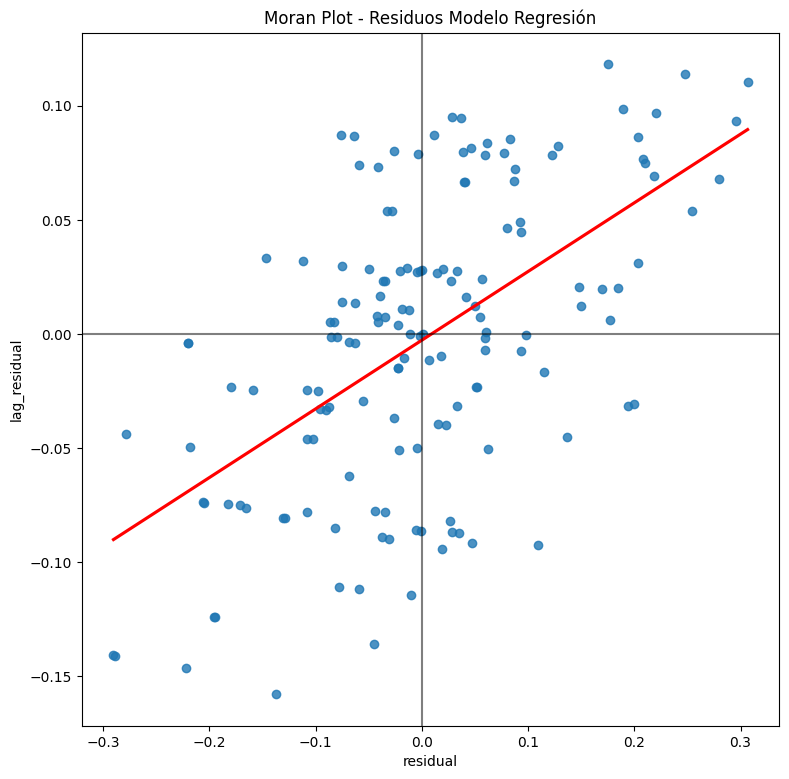

In [22]:
# Create column with residual values from m1
train["residual"] = m1.u
train["lag_residual"] = weights.spatial_lag.lag_spatial(wq, m1.u)

f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="residual",
    y="lag_residual",
    ci=None,
    data=train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - Residuos Modelo Regresión")
plt.show()

In [23]:
# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(train["residual"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

I de moran: 0.301
p-valor: 0.001


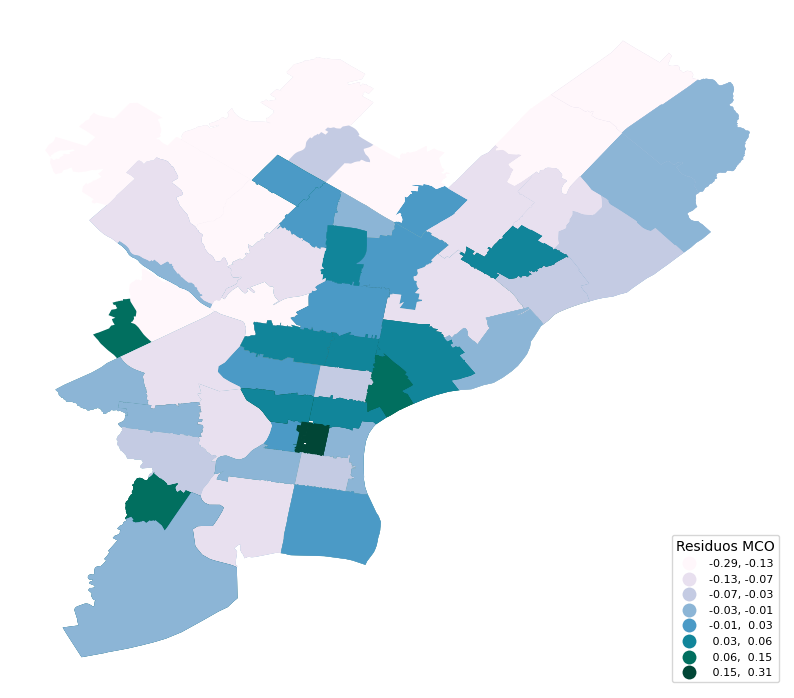

In [24]:
# representación de los residuos MCO  retardada
map=train.plot(column='residual', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Residuos MCO'} 
)
map.set_axis_off()

## Modelo Espacial

In [25]:
train.columns

Index(['index', 'ZCTA', 'time_of_day', 'geometry', 'population', 'white_race',
       'black_race', 'latino_race', 'asian_race', 'mean_income',
       'median_income', 'total_households', 'household_25k_or_less',
       'household_25k_to_50k', 'household_50k_to_150k',
       'household_150k_or_more', 'GiniIndex', 'risk_score', 'risk_score_lag',
       'p-sim', 'sig', 'labels', 'residual', 'lag_residual'],
      dtype='object')

In [26]:
# Reordenar para que Morning sea la primera categoría alfabéticamente
train["time_of_day_reordered"] = train["time_of_day"].replace({
    'Afternoon': 'B_Afternoon',  # B para que sea segunda
    'Morning': 'A_Morning',      # A para que sea primera (se elimina)
    'Night': 'C_Night'           # C para que sea tercera
})

# Crear dummies (ahora Morning se eliminará)
dummies = pd.get_dummies(train["time_of_day_reordered"], prefix="time", drop_first=True)

# Limpiar nombres de columnas
dummies.columns = [col.replace('time_B_', 'time_').replace('time_C_', 'time_') 
                   for col in dummies.columns]

# Concatenar con tus features
X = pd.concat([train[["GiniIndex"]], dummies], axis=1).astype(float).values
y = train[["risk_score"]].values

In [27]:
# Concatenar con tus features
X = train[["GiniIndex"]].astype(float).values
y = train[["risk_score"]].values

In [28]:
# (Modelo autoregresivo espacial - estimado por MC2E)
mLag = spreg.GM_Lag(    
    # Dependent variable
    y=y,
    # Independent variables
    x=X,
    # Spatial weights matrix
    w= wq,
    robust='white',
    # Numero de retardos
    w_lags=3,
    #para el modelo de durbin slx_lags >0
    # slx_lags = 1, 
    #diagnósitico de correlación espacial
    spat_diag=True,
    # Dependent variable name
    name_y="risk_score",
    # Independent variable name
    name_x=["GiniIndex"], #, 'time_Afternoon', 'time_Night' 
    name_w=" Contiguidad Reina",
    name_ds=" Índice de Criminalidad en Filadelfia"
    
)

print(mLag.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            : Índice de Criminalidad en Filadelfia
Weights matrix      : Contiguidad Reina
Dependent Variable  :  risk_score                Number of Observations:         150
Mean dependent var  :      0.2848                Number of Variables   :           3
S.D. dependent var  :      0.1411                Degrees of Freedom    :         147
Pseudo R-squared    :      0.5620
Spatial Pseudo R-squared:  0.3848

White Standard Errors
------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        -0.34027         0.07660        -4.44191         0.00001
           GiniIndex         0.76810         0.16869         4.55343      

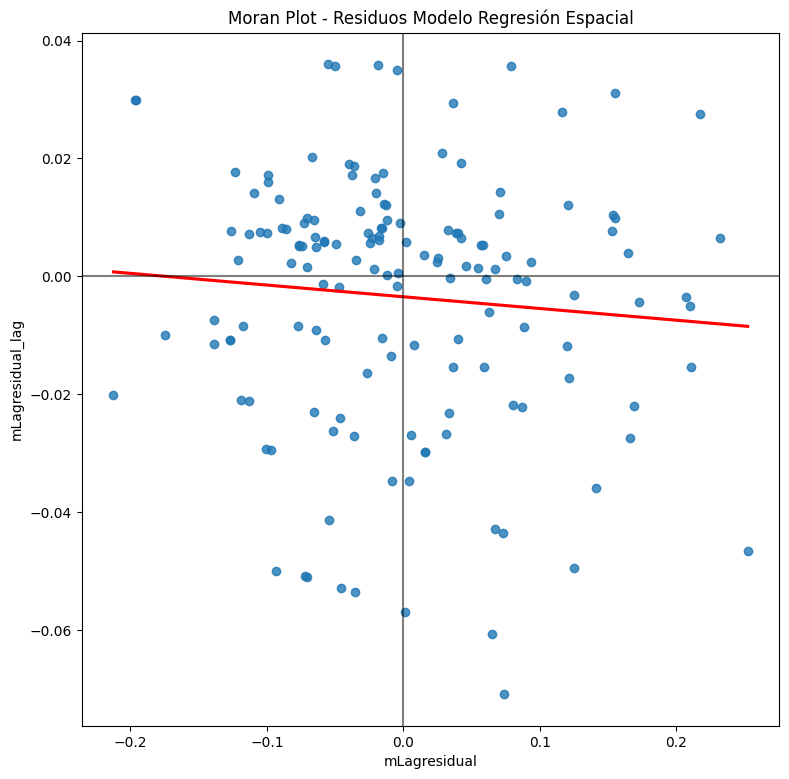

In [29]:
# Create column with residual values from m1
train["mLagresidual"] = mLag.u
train["mLagresidual_lag"] = weights.spatial_lag.lag_spatial(wq, mLag.u)

f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="mLagresidual",
    y="mLagresidual_lag",
    ci=None,
    data=train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - Residuos Modelo Regresión Espacial")
plt.show()

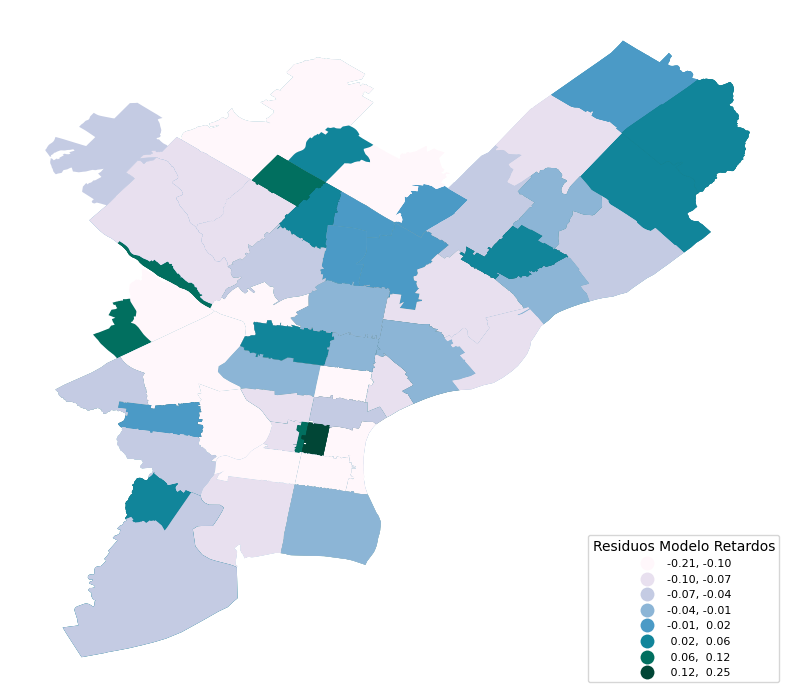

In [30]:
# representación de los residuos Modelo Retardado
map=train.plot(column='mLagresidual', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Residuos Modelo Retardos'} 
)
map.set_axis_off() 


## Predicciones

In [31]:
df_test = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Test/df_test_with_score_ZCTACoordinates.shp'))
df_test = df_test[(df_test['date'] >= '2025-01-01')]

In [33]:
# Se hace agrupamiento
aggregate_df_test_raw = df_test.groupby(['ZCTA', 'hour']).agg({
    'geometry': 'first',
    'population' : 'first',
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# aggregate_df_test_raw.to_csv("RiskScore_MediaZCTA_Test.csv")

# Se remueven NAs
aggregate_df_test = aggregate_df_test_raw.dropna().reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_test = gpd.GeoDataFrame(aggregate_df_test, geometry='geometry')

In [34]:
test = aggregate_df_test.copy()

In [35]:
# Crear matriz de pesos de contigüidad reina para validación
wq_test = weights.Queen.from_dataframe(test)

# Normalizar (como hiciste en training)
wq_test.transform = 'r'

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_2508\3216524482.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq_test = weights.Queen.from_dataframe(test)


In [36]:
# Generar variables dummy
dummies = pd.get_dummies(test["hour"], prefix="time", drop_first=True)

# Concatenar con tus features
X_val = pd.concat([test[["GiniIndex"]], dummies], axis=1).astype(float).values
y_val = test[["risk_score"]].values

In [36]:
# Concatenar con tus features
X_val = test[["GiniIndex"]].astype(float).values
y_val = test[["risk_score"]].values

In [37]:
betas = np.array(mLag.betas).flatten()
intercept = betas[0]
coefs = betas[1:-1]   # todas las covariables excepto rho
rho = betas[-1]

# Construcción de Xβ con todas las variables de una vez
Xbeta = intercept + X_val.dot(coefs)

In [38]:
# 3) Matriz de pesos espaciales (misma del entrenamiento)
W_test, ids = wq_test.full()
n = W_test.shape[0]

In [39]:
# 4) Resolver el sistema (I - rho W) y = Xβ
I = np.eye(n)
M = I - rho * W_test   
Xbeta_vec = Xbeta.reshape(-1, 1)

In [40]:
try:
    y_val_pred = np.linalg.solve(M, Xbeta_vec).flatten()
except np.linalg.LinAlgError:
    print("Advertencia: (I - rho W) es singular; usando pseudo-inversa")
    y_val_pred = np.linalg.pinv(M).dot(Xbeta_vec).flatten()

In [41]:
y_val.flatten()

array([0.05682926, 0.02109947, 0.25471186, ..., 0.13623181, 0.13623181,
       0.03904316])

In [42]:
y_val_pred

array([0.40372291, 0.21985367, 0.36731163, ..., 0.01174758, 0.01174758,
       0.27896109])

RMSE: 0.1395
R²:   0.2646


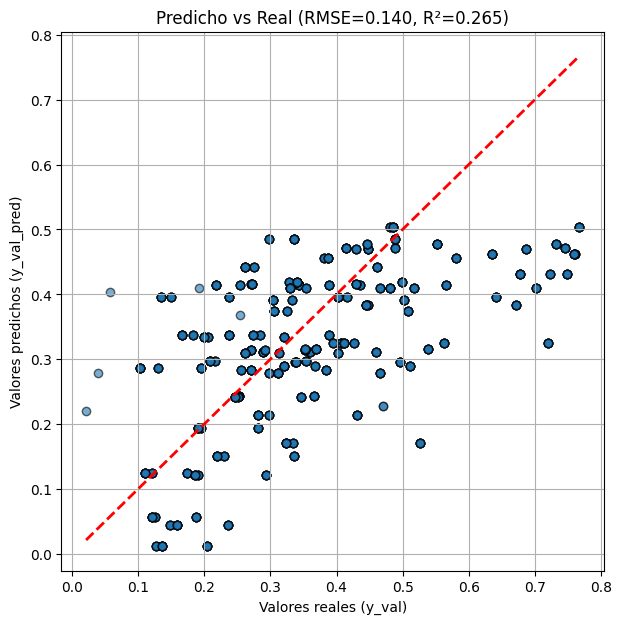

In [43]:
# 1) Valores reales y predichos
y_true = y_val.flatten()
y_pred = y_val_pred

# 2) Métricas
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# 3) Scatter plot Predicho vs Real
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Valores reales (y_val)")
plt.ylabel("Valores predichos (y_val_pred)")
plt.title(f"Predicho vs Real (RMSE={rmse:.3f}, R²={r2:.3f})")
plt.grid(True)
plt.show()

In [46]:
df_resultados = pd.DataFrame({
    'y_true': y_val.flatten(),
    'y_pred': y_val_pred
})

df_resultados.head(100)

,y_true,y_pred
0,0.056829,0.403723
1,0.021099,0.219854
2,0.254712,0.367312
3,0.192182,0.409798
4,0.634997,0.461989
...,...,...
95,0.388034,0.337742
96,0.236707,0.337742
97,0.236707,0.337742
98,0.236707,0.337742
